In [1]:
!pip install -q transformers peft accelerate biopython einops
!pip install -q -U torchao

In [18]:
!wget -q "https://github.com/pr2database/pr2database/releases/download/v5.1.1/pr2_version_5.1.1_SSU_taxo_long.fasta.gz" -O pr2.fasta.gz
!gunzip -f pr2.fasta.gz
!ls -lh pr2.fasta
!grep -c "^>" pr2.fasta

-rw-r--r-- 1 root root 352M Oct 27  2025 pr2.fasta
240201


In [19]:
from collections import defaultdict

def parse_pr2(fasta_path):
    records = []
    header = None
    seq_chunks = []

    with open(fasta_path) as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(seq_chunks)))
                header = line[1:]
                seq_chunks = []
            else:
                seq_chunks.append(line)
        if header is not None:
            records.append((header, "".join(seq_chunks)))

    parsed = []
    skipped = 0
    for header, seq in records:
        fields = header.split("|")
        if len(fields) < 13:
            skipped += 1
            continue
        taxonomy_fields = fields[4:13]  # domain..species, 9 levels
        species = taxonomy_fields[-1]
        genus = taxonomy_fields[-2]
        seq = seq.upper().replace("U", "T")
        if len(seq) >= 100:
            parsed.append({
                "accession": fields[0], "sequence": seq,
                "taxonomy": taxonomy_fields, "species": species, "genus": genus,
            })
        else:
            skipped += 1
    return parsed, skipped


records, skipped = parse_pr2("pr2.fasta")
print(f"Parsed: {len(records)}  Skipped: {skipped}")

by_species = defaultdict(list)
for r in records:
    by_species[r["species"]].append(r["sequence"])
by_species = {k: v for k, v in by_species.items() if len(v) >= 2}
species_list = list(by_species.keys())
print(f"Usable species (>=2 sequences): {len(species_list)}")

Parsed: 240201  Skipped: 0
Usable species (>=2 sequences): 20046


In [20]:
import torch
import sys
from transformers import AutoConfig, AutoTokenizer, AutoModel
from huggingface_hub import hf_hub_download

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

def load_dnabert_s():
    MODEL_NAME = "zhihan1996/DNABERT-S"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

    config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)
    config.pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

    model = AutoModel.from_config(config, trust_remote_code=True)

    for name, mod in list(sys.modules.items()):
        if name.endswith("bert_layers") and "DNABERT" in name:
            mod.flash_attn_qkvpacked_func = None

    weights_path = hf_hub_download(MODEL_NAME, "pytorch_model.bin")
    state_dict = torch.load(weights_path, map_location="cpu")
    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    print("Missing keys:", missing)
    print("Unexpected keys:", unexpected)

    model.to(DEVICE)
    return tokenizer, model

tokenizer, model = load_dnabert_s()
print("DNABERT-S base model ready.")

Using device: cuda
Missing keys: []
Unexpected keys: []
DNABERT-S base model ready.


In [21]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["Wqkv", "attention.output.dense"],
    lora_dropout=0.05,
    bias="none",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
model.to(DEVICE)
model.train()

trainable params: 442,368 || all params: 117,510,912 || trainable%: 0.3764


PeftModel(
  (base_model): LoraModel(
    (model): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(4096, 768, padding_idx=3)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertUnpadAttention(
              (self): BertUnpadSelfAttention(
                (dropout): Dropout(p=0.0, inplace=False)
                (Wqkv): lora.Linear(
                  (base_layer): Linear(in_features=768, out_features=2304, bias=True)
                  (lora_dropout): ModuleDict(
                    (default): Dropout(p=0.05, inplace=False)
                  )
                  (lora_A): ModuleDict(
                    (default): Linear(in_features=768, out_features=8, bias=False)
                  )
                  (lo

In [22]:
import random
from torch.utils.data import Dataset, DataLoader

class TripletBarcodeDataset(Dataset):
    def __init__(self, by_species, species_list, length=20000, max_len=512):
        self.by_species = by_species
        self.species_list = species_list
        self.length = length
        self.max_len = max_len

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        sp = random.choice(self.species_list)
        seqs = self.by_species[sp]
        anchor, positive = random.sample(seqs, 2)
        neg_sp = random.choice(self.species_list)
        while neg_sp == sp:
            neg_sp = random.choice(self.species_list)
        negative = random.choice(self.by_species[neg_sp])
        return anchor[:self.max_len], positive[:self.max_len], negative[:self.max_len]

def collate(batch):
    anchors, positives, negatives = zip(*batch)
    return list(anchors), list(positives), list(negatives)

random.seed(42)
shuffled_species = species_list.copy()
random.shuffle(shuffled_species)

val_frac = 0.1
n_val = int(len(shuffled_species) * val_frac)
val_species = shuffled_species[:n_val]
train_species = shuffled_species[n_val:]

print(f"Train species: {len(train_species)}  Val species: {len(val_species)}")

train_dataset = TripletBarcodeDataset(by_species, train_species, length=20000)
val_dataset = TripletBarcodeDataset(by_species, val_species, length=2000)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate)

print(f"Train batches/epoch: {len(train_loader)}  Val batches: {len(val_loader)}")

Train species: 18042  Val species: 2004
Train batches/epoch: 1250  Val batches: 125


In [24]:
from tqdm.auto import tqdm
import torch.nn as nn
import torch.nn.functional as F

def embed_batch(seqs, tokenizer, model, max_len=512):
    enc = tokenizer(seqs, return_tensors="pt", padding=True, truncation=True, max_length=max_len)
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    out = model(input_ids=enc["input_ids"])[0]
    mask = enc["attention_mask"].unsqueeze(-1).float()
    pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
    return F.normalize(pooled, dim=-1)


def compute_accuracy(a_emb, p_emb, n_emb):
    pos_dist = (a_emb - p_emb).norm(dim=1)
    neg_dist = (a_emb - n_emb).norm(dim=1)
    return (pos_dist < neg_dist).float().mean().item()


def run_validation(model, val_loader, tokenizer, loss_fn):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    with torch.no_grad():
        for anchors, positives, negatives in val_loader:
            a_emb = embed_batch(anchors, tokenizer, model)
            p_emb = embed_batch(positives, tokenizer, model)
            n_emb = embed_batch(negatives, tokenizer, model)
            loss = loss_fn(a_emb, p_emb, n_emb)
            total_loss += loss.item()
            total_acc += compute_accuracy(a_emb, p_emb, n_emb)
    model.train()
    return total_loss / len(val_loader), total_acc / len(val_loader)


EPOCHS = 15
PATIENCE = 3
SAVE_DIR = "/kaggle/working/dnabert_s_lora_18s_best"

triplet_loss_fn = nn.TripletMarginLoss(margin=0.3)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=1
)

best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    running_acc = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}", leave=True)
    for step, (anchors, positives, negatives) in enumerate(pbar):
        optimizer.zero_grad()
        a_emb = embed_batch(anchors, tokenizer, model)
        p_emb = embed_batch(positives, tokenizer, model)
        n_emb = embed_batch(negatives, tokenizer, model)
        loss = triplet_loss_fn(a_emb, p_emb, n_emb)
        loss.backward()
        optimizer.step()

        acc = compute_accuracy(a_emb, p_emb, n_emb)
        running_loss += loss.item()
        running_acc += acc

        pbar.set_postfix({
            "loss": f"{running_loss/(step+1):.4f}",
            "acc": f"{running_acc/(step+1):.3f}"
        })

    train_loss = running_loss / len(train_loader)
    train_acc = running_acc / len(train_loader)
    val_loss, val_acc = run_validation(model, val_loader, tokenizer, triplet_loss_fn)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch}: train_loss={train_loss:.4f} train_acc={train_acc:.3f}  val_loss={val_loss:.4f} val_acc={val_acc:.3f}  lr={current_lr:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f"  -> New best val_loss {val_loss:.4f}. Saved to {SAVE_DIR}")
    else:
        epochs_without_improvement += 1
        print(f"  -> No improvement ({epochs_without_improvement}/{PATIENCE})")
        if epochs_without_improvement >= PATIENCE:
            print("Early stopping triggered.")
            break

print(f"Training done. Best val_loss: {best_val_loss:.4f}")

Epoch 0:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 0: train_loss=0.0285 train_acc=0.968  val_loss=0.0162 val_acc=0.982  lr=2.00e-04
  -> New best val_loss 0.0162. Saved to /kaggle/working/dnabert_s_lora_18s_best


Epoch 1:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 1: train_loss=0.0178 train_acc=0.981  val_loss=0.0148 val_acc=0.984  lr=2.00e-04
  -> New best val_loss 0.0148. Saved to /kaggle/working/dnabert_s_lora_18s_best


Epoch 2:   0%|          | 0/1250 [00:00<?, ?it/s]

...

Epoch 11: train_loss=0.0057 train_acc=0.994  val_loss=0.0070 val_acc=0.993  lr=1.00e-04
  -> No improvement (1/3)


Epoch 12:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 12: train_loss=0.0063 train_acc=0.994  val_loss=0.0071 val_acc=0.991  lr=5.00e-05
  -> No improvement (2/3)


Epoch 13:   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 13: train_loss=0.0062 train_acc=0.994  val_loss=0.0064 val_acc=0.994  lr=5.00e-05
  -> No improvement (3/3)
Early stopping triggered.
Training done. Best val_loss: 0.0061


In [25]:
!pip install -q umap-learn

Sampled 99 sequences across 40 held-out species
Embeddings shape: (99, 768)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


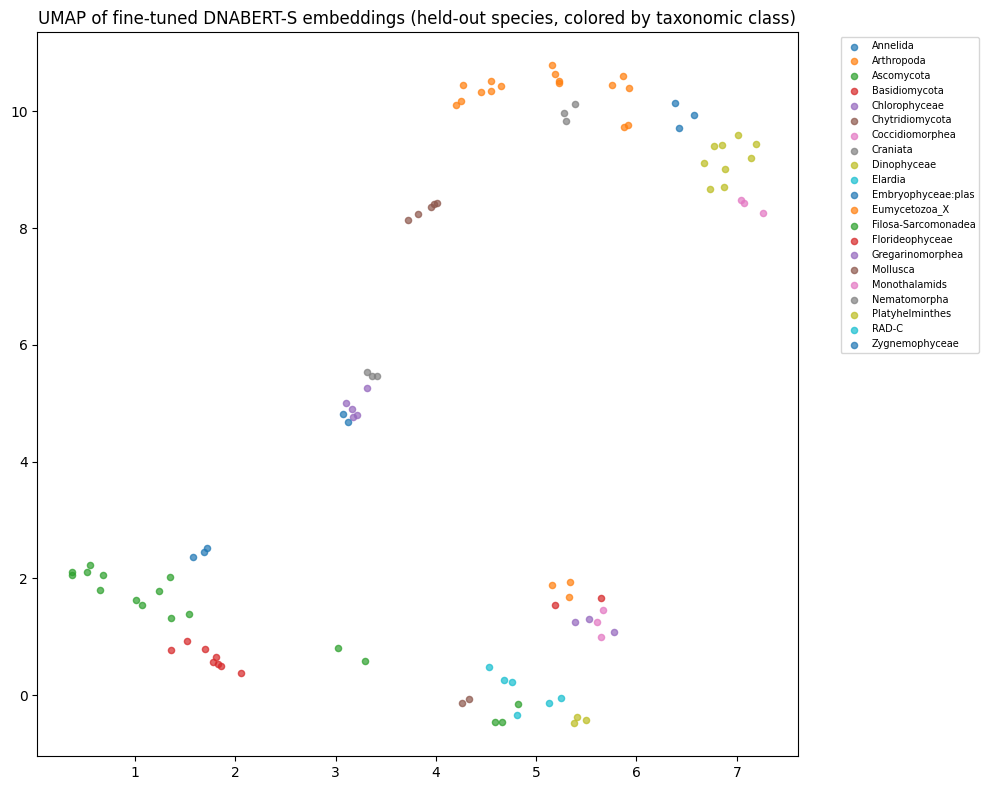

In [26]:
import umap
import numpy as np
import matplotlib.pyplot as plt

# Build a lookup from species -> full taxonomy (we have this from `records`)
species_to_taxonomy = {}
for r in records:
    species_to_taxonomy[r["species"]] = r["taxonomy"]

# Sample sequences from held-out validation species only —
# this checks whether embeddings generalize, not just memorize
random.seed(0)
sample_species = random.sample(val_species, min(40, len(val_species)))

sample_seqs = []
sample_labels = []  # class-level taxonomy (index 4 in the 9-level list: domain,supergroup,division,subdivision,class,...)
for sp in sample_species:
    for seq in by_species[sp][:3]:  # up to 3 sequences per species
        sample_seqs.append(seq[:512])
        sample_labels.append(species_to_taxonomy[sp][4])  # class level

print(f"Sampled {len(sample_seqs)} sequences across {len(sample_species)} held-out species")

model.eval()
all_embeddings = []
batch_size = 16
with torch.no_grad():
    for i in range(0, len(sample_seqs), batch_size):
        batch = sample_seqs[i:i+batch_size]
        emb = embed_batch(batch, tokenizer, model)
        all_embeddings.append(emb.cpu().numpy())
all_embeddings = np.concatenate(all_embeddings, axis=0)
print("Embeddings shape:", all_embeddings.shape)

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=42)
coords_2d = reducer.fit_transform(all_embeddings)

unique_classes = sorted(set(sample_labels))
cmap = plt.get_cmap("tab20", len(unique_classes))
color_map = {cls: cmap(i) for i, cls in enumerate(unique_classes)}
colors = [color_map[c] for c in sample_labels]

plt.figure(figsize=(10, 8))
for cls in unique_classes:
    idxs = [i for i, c in enumerate(sample_labels) if c == cls]
    plt.scatter(coords_2d[idxs, 0], coords_2d[idxs, 1], label=cls, s=20, alpha=0.7)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7)
plt.title("UMAP of fine-tuned DNABERT-S embeddings (held-out species, colored by taxonomic class)")
plt.tight_layout()
plt.savefig("/kaggle/working/umap_sanity_check.png", dpi=150)
plt.show()

In [27]:
!pip install -q faiss-gpu-cu12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 41.4 MB/s eta 0:00:00:00:0100:01


In [28]:
import faiss
import numpy as np

model.eval()

def embed_all(seqs, batch_size=32):
    all_emb = []
    with torch.no_grad():
        for i in tqdm(range(0, len(seqs), batch_size), desc="Embedding"):
            batch = [s[:512] for s in seqs[i:i+batch_size]]
            emb = embed_batch(batch, tokenizer, model)
            all_emb.append(emb.cpu().numpy())
    return np.concatenate(all_emb, axis=0)

# Embed every reference sequence (all 240,201 — this will take a while on GPU, but it's a one-time cost)
ref_sequences = [r["sequence"] for r in records]
ref_taxonomy = [r["taxonomy"] for r in records]
ref_species = [r["species"] for r in records]

ref_embeddings = embed_all(ref_sequences)
print("Reference embeddings shape:", ref_embeddings.shape)

# Build FAISS index (cosine similarity via normalized inner product)
faiss.normalize_L2(ref_embeddings)
index = faiss.IndexFlatIP(ref_embeddings.shape[1])
index.add(ref_embeddings)
print("FAISS index size:", index.ntotal)

# Save everything so we don't have to re-embed 240K sequences again
np.save("/kaggle/working/ref_embeddings.npy", ref_embeddings)
faiss.write_index(index, "/kaggle/working/pr2_faiss.index")
import pickle
with open("/kaggle/working/ref_metadata.pkl", "wb") as f:
    pickle.dump({"taxonomy": ref_taxonomy, "species": ref_species}, f)

print("Saved index and metadata.")

Embedding:   0%|          | 0/7507 [00:00<?, ?it/s]

Reference embeddings shape: (240201, 768)
FAISS index size: 240201
Saved index and metadata.


In [31]:
def classify_read(seq, k=15, similarity_threshold=0.85, agreement_threshold=0.7, exact_match_threshold=0.999):
    model.eval()
    with torch.no_grad():
        emb = embed_batch([seq[:512]], tokenizer, model).cpu().numpy()
    faiss.normalize_L2(emb)

    similarities, indices = index.search(emb, k)
    similarities = similarities[0]
    indices = indices[0]
    top_sim = float(similarities[0])

    if top_sim < similarity_threshold:
        return {
            "assignment": None, "deepest_rank": None, "confidence": top_sim,
            "novel_candidate": True,
            "nearest_known_relative": ref_taxonomy[indices[0]],
            "nearest_similarity": top_sim,
            "method": "no_match",
        }

    # Near-exact match: trust the single top hit directly, skip voting
    if top_sim >= exact_match_threshold:
        return {
            "assignment": ref_taxonomy[indices[0]],
            "deepest_rank": "species",
            "confidence": top_sim,
            "novel_candidate": False,
            "nearest_known_relative": ref_taxonomy[indices[0]],
            "nearest_similarity": top_sim,
            "method": "exact_match",
        }

    # Otherwise: hierarchical majority vote with pool narrowing
    candidate_pool = list(range(len(indices)))
    assignment = []
    deepest_rank = None

    for rank_idx, rank_name in enumerate(RANK_NAMES):
        pool_values = [ref_taxonomy[indices[i]][rank_idx] for i in candidate_pool]
        most_common, count = Counter(pool_values).most_common(1)[0]
        agreement = count / len(pool_values)

        if agreement >= agreement_threshold:
            assignment.append(most_common)
            deepest_rank = rank_name
            candidate_pool = [i for i in candidate_pool if ref_taxonomy[indices[i]][rank_idx] == most_common]
        else:
            break

    return {
        "assignment": assignment,
        "deepest_rank": deepest_rank,
        "confidence": top_sim,
        "novel_candidate": (deepest_rank is None or RANK_NAMES.index(deepest_rank) < 4),
        "nearest_known_relative": ref_taxonomy[indices[0]],
        "nearest_similarity": top_sim,
        "method": "voted",
    }


result = classify_read(ref_sequences[0])
print("Known sequence test:")
print(result)
print()

result2 = classify_read(by_species[val_species[0]][0])
print(f"Held-out species test (true species: {val_species[0]}):")
print(result2)

Known sequence test:
{'assignment': ['Eukaryota', 'TSAR', 'Alveolata', 'Dinoflagellata', 'Dinophyceae'], 'deepest_rank': 'class', 'confidence': 0.9967072010040283, 'novel_candidate': False, 'nearest_known_relative': ['Eukaryota', 'TSAR', 'Alveolata', 'Dinoflagellata', 'Dinophyceae', 'Peridiniales', 'Kryptoperidiniaceae', 'Unruhdinium', 'Unruhdinium_kevei'], 'nearest_similarity': 0.9967072010040283, 'method': 'voted'}

Held-out species test (true species: Spio_filicornis):
{'assignment': ['Eukaryota', 'Obazoa', 'Opisthokonta', 'Metazoa', 'Annelida', 'Annelida_X', 'Annelida_XX', 'Spio', 'Spio_filicornis'], 'deepest_rank': 'species', 'confidence': 0.9996414184570312, 'novel_candidate': False, 'nearest_known_relative': ['Eukaryota', 'Obazoa', 'Opisthokonta', 'Metazoa', 'Annelida', 'Annelida_X', 'Annelida_XX', 'Spio', 'Spio_filicornis'], 'nearest_similarity': 0.9996414184570312, 'method': 'exact_match'}


In [32]:
result = classify_read(ref_sequences[0], exact_match_threshold=0.995)
print("Known sequence test (relaxed threshold):")
print(result)

Known sequence test (relaxed threshold):
{'assignment': ['Eukaryota', 'TSAR', 'Alveolata', 'Dinoflagellata', 'Dinophyceae', 'Peridiniales', 'Kryptoperidiniaceae', 'Unruhdinium', 'Unruhdinium_kevei'], 'deepest_rank': 'species', 'confidence': 0.9967072010040283, 'novel_candidate': False, 'nearest_known_relative': ['Eukaryota', 'TSAR', 'Alveolata', 'Dinoflagellata', 'Dinophyceae', 'Peridiniales', 'Kryptoperidiniaceae', 'Unruhdinium', 'Unruhdinium_kevei'], 'nearest_similarity': 0.9967072010040283, 'method': 'exact_match'}


In [33]:
# Pick a species to remove entirely from the reference index (simulating a truly unknown organism)
novel_test_species = val_species[5]
novel_test_seq = by_species[novel_test_species][0]
print(f"Testing with species held OUT of the reference index: {novel_test_species}")

# Build a temporary index excluding every sequence belonging to this species
exclude_mask = np.array([sp != novel_test_species for sp in ref_species])
filtered_embeddings = ref_embeddings[exclude_mask]
filtered_taxonomy = [t for t, keep in zip(ref_taxonomy, exclude_mask) if keep]

faiss.normalize_L2(filtered_embeddings)
temp_index = faiss.IndexFlatIP(filtered_embeddings.shape[1])
temp_index.add(filtered_embeddings)

# temporarily swap in the filtered index for this test
_original_index, _original_taxonomy = index, ref_taxonomy
index, ref_taxonomy = temp_index, filtered_taxonomy

result_novel = classify_read(novel_test_seq, exact_match_threshold=0.995)
print("Result when species is genuinely absent from the reference database:")
print(result_novel)

# restore the real index
index, ref_taxonomy = _original_index, _original_taxonomy

Testing with species held OUT of the reference index: Nonionella_basispinata
Result when species is genuinely absent from the reference database:
{'assignment': ['Eukaryota', 'TSAR', 'Rhizaria', 'Foraminifera', 'Globothalamea', 'Rotaliida'], 'deepest_rank': 'order', 'confidence': 0.9305275082588196, 'novel_candidate': False, 'nearest_known_relative': ['Eukaryota', 'TSAR', 'Rhizaria', 'Foraminifera', 'Globothalamea', 'Rotaliida', 'Nonionidae', 'Nonionella', 'Nonionella_auris'], 'nearest_similarity': 0.9305275082588196, 'method': 'voted'}


In [36]:
genus_counts = Counter(r["genus"] for r in records)
candidate_genera = [g for g, c in genus_counts.items() if c >= 3]
test_genus = random.choice(candidate_genera)

test_seq_for_genus = None
for r in records:
    if r["genus"] == test_genus:
        test_seq_for_genus = r["sequence"]
        break

print(f"Testing with entire genus held OUT of the reference index: {test_genus}")

exclude_mask = np.array([r["genus"] != test_genus for r in records])
filtered_embeddings = ref_embeddings[exclude_mask]
filtered_taxonomy = [t for t, keep in zip(ref_taxonomy, exclude_mask) if keep]

faiss.normalize_L2(filtered_embeddings)
temp_index = faiss.IndexFlatIP(filtered_embeddings.shape[1])
temp_index.add(filtered_embeddings)

_original_index, _original_taxonomy = index, ref_taxonomy
index, ref_taxonomy = temp_index, filtered_taxonomy

result_genus_novel = classify_read(test_seq_for_genus, exact_match_threshold=0.995)
print("Result when entire genus is absent from the reference database:")
print(result_genus_novel)

index, ref_taxonomy = _original_index, _original_taxonomy

Testing with entire genus held OUT of the reference index: Phoenix:plas
Result when entire genus is absent from the reference database:
{'assignment': ['Eukaryota:plas', 'Archaeplastida:plas', 'Streptophyta:plas', 'Streptophyta_X:plas', 'Embryophyceae:plas', 'Embryophyceae_X:plas', 'Embryophyceae_XX:plas', 'Cocos:plas', 'Cocos_nucifera:plas'], 'deepest_rank': 'species', 'confidence': 0.9996988773345947, 'novel_candidate': False, 'nearest_known_relative': ['Eukaryota:plas', 'Archaeplastida:plas', 'Streptophyta:plas', 'Streptophyta_X:plas', 'Embryophyceae:plas', 'Embryophyceae_X:plas', 'Embryophyceae_XX:plas', 'Cocos:plas', 'Cocos_nucifera:plas'], 'nearest_similarity': 0.9996988773345947, 'method': 'exact_match'}


In [37]:
def classify_read(seq, k=15, similarity_threshold=0.85, agreement_threshold=0.8):
    model.eval()
    with torch.no_grad():
        emb = embed_batch([seq[:512]], tokenizer, model).cpu().numpy()
    faiss.normalize_L2(emb)

    similarities, indices = index.search(emb, k)
    similarities = similarities[0]
    indices = indices[0]
    top_sim = float(similarities[0])

    if top_sim < similarity_threshold:
        return {
            "assignment": None, "deepest_rank": None, "confidence": top_sim,
            "novel_candidate": True,
            "nearest_known_relative": ref_taxonomy[indices[0]],
            "nearest_similarity": top_sim, "method": "no_match",
        }

    # No more raw-similarity shortcut — always require neighbor pool agreement,
    # even for very high similarity, since conserved markers can be misleading
    candidate_pool = list(range(len(indices)))
    assignment = []
    deepest_rank = None

    for rank_idx, rank_name in enumerate(RANK_NAMES):
        pool_values = [ref_taxonomy[indices[i]][rank_idx] for i in candidate_pool]
        most_common, count = Counter(pool_values).most_common(1)[0]
        agreement = count / len(pool_values)

        if agreement >= agreement_threshold:
            assignment.append(most_common)
            deepest_rank = rank_name
            candidate_pool = [i for i in candidate_pool if ref_taxonomy[indices[i]][rank_idx] == most_common]
        else:
            break

    return {
        "assignment": assignment,
        "deepest_rank": deepest_rank,
        "confidence": top_sim,
        "novel_candidate": (deepest_rank is None or RANK_NAMES.index(deepest_rank) < 4),
        "nearest_known_relative": ref_taxonomy[indices[0]],
        "nearest_similarity": top_sim,
        "method": "voted",
    }

result_genus_novel = classify_read(test_seq_for_genus)
print(result_genus_novel)

{'assignment': ['Eukaryota:plas', 'Archaeplastida:plas', 'Streptophyta:plas', 'Streptophyta_X:plas', 'Embryophyceae:plas', 'Embryophyceae_X:plas', 'Embryophyceae_XX:plas'], 'deepest_rank': 'family', 'confidence': 0.9996988773345947, 'novel_candidate': False, 'nearest_known_relative': ['Eukaryota:plas', 'Archaeplastida:plas', 'Streptophyta:plas', 'Streptophyta_X:plas', 'Embryophyceae:plas', 'Embryophyceae_X:plas', 'Embryophyceae_XX:plas', 'Cocos:plas', 'Cocos_nucifera:plas'], 'nearest_similarity': 0.9996988773345947, 'method': 'voted'}


In [39]:
def cluster_novel_reads(results, embeddings, min_cluster_size=3):
    novel_idx = [i for i, r in enumerate(results) if r["novel_candidate"]]
    if len(novel_idx) < min_cluster_size:
        print(f"Only {len(novel_idx)} novel reads found — not enough to cluster meaningfully.")
        return [], None, None, novel_idx

    novel_embeddings = embeddings[novel_idx]  # already L2-normalized from process_read_batch

    # Cluster directly in embedding space (cosine distance) — more reliable than post-UMAP for small batches
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric="euclidean")
    cluster_labels = clusterer.fit_predict(novel_embeddings)

    # UMAP purely for visualization, computed AFTER clustering decision is made
    n_neighbors = max(2, min(15, len(novel_idx) - 1))
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1, metric="cosine", random_state=42)
    coords_2d = reducer.fit_transform(novel_embeddings)

    candidate_taxa = []
    for cluster_id in set(cluster_labels):
        if cluster_id == -1:
            continue
        members = [novel_idx[i] for i, c in enumerate(cluster_labels) if c == cluster_id]
        relatives = [tuple(results[m]["nearest_known_relative"]) for m in members]
        common_relative = Counter(relatives).most_common(1)[0][0]
        candidate_taxa.append({
            "cluster_id": int(cluster_id),
            "num_reads": len(members),
            "member_indices": members,
            "nearest_known_relative": list(common_relative),
        })

    return candidate_taxa, coords_2d, cluster_labels, novel_idx


# Rerun demo with more simulated-novel reads for a clearer signal
random.seed(1)
demo_species = random.sample(species_list, 30)
demo_sequences = [by_species[sp][0] for sp in demo_species]

novel_seed = by_species[random.choice(species_list)][0]
simulated_novel = [mutate_sequence(novel_seed, mutation_rate=0.12) for _ in range(10)]
demo_sequences += simulated_novel

results, embeddings = process_read_batch(demo_sequences)
novel_count = sum(1 for r in results if r["novel_candidate"])
print(f"Batch of {len(demo_sequences)} reads: {novel_count} flagged as novel candidates")

candidate_taxa, coords_2d, cluster_labels, novel_idx = cluster_novel_reads(results, embeddings)
print(f"Found {len(candidate_taxa)} candidate novel taxon clusters")
for ct in candidate_taxa:
    print(ct)

Embedding:   0%|          | 0/2 [00:00<?, ?it/s]

Batch of 40 reads: 7 flagged as novel candidates
Found 0 candidate novel taxon clusters


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [40]:
print("Novel-flagged reads:")
for i in novel_idx:
    source = "SIMULATED" if i >= 30 else f"real ({demo_species[i]})"
    print(f"  idx {i}: {source}  novel_candidate={results[i]['novel_candidate']}  confidence={results[i]['confidence']:.4f}")

print()
novel_embeddings = embeddings[novel_idx]
sim_matrix = novel_embeddings @ novel_embeddings.T  # already L2-normalized, so this is cosine similarity
print("Pairwise similarity among novel-flagged reads:")
print(np.round(sim_matrix, 3))

Novel-flagged reads:
  idx 13: real (Monosiga_ovata)  novel_candidate=True  confidence=0.9994
  idx 20: real (Piscirickettsia_sp.)  novel_candidate=True  confidence=0.9998
  idx 30: SIMULATED  novel_candidate=True  confidence=0.8064
  idx 33: SIMULATED  novel_candidate=True  confidence=0.8315
  idx 34: SIMULATED  novel_candidate=True  confidence=0.7951
  idx 35: SIMULATED  novel_candidate=True  confidence=0.8127
  idx 36: SIMULATED  novel_candidate=True  confidence=0.8250

Pairwise similarity among novel-flagged reads:
[[ 1.    -0.102  0.596  0.392  0.397  0.31   0.162]
 [-0.102  1.    -0.127 -0.159  0.11   0.075  0.084]
 [ 0.596 -0.127  1.     0.655  0.546  0.446  0.466]
 [ 0.392 -0.159  0.655  1.     0.38   0.464  0.389]
 [ 0.397  0.11   0.546  0.38   1.     0.678  0.681]
 [ 0.31   0.075  0.446  0.464  0.678  1.     0.712]
 [ 0.162  0.084  0.466  0.389  0.681  0.712  1.   ]]


In [41]:
def cluster_novel_reads(results, embeddings, similarity_threshold=0.85, min_cluster_size=2):
    # True novelty = low raw similarity, not rank-voting disagreement
    novel_idx = [i for i, r in enumerate(results) if r["confidence"] < similarity_threshold]
    if len(novel_idx) < min_cluster_size:
        print(f"Only {len(novel_idx)} truly novel reads found.")
        return [], None, None, novel_idx

    novel_embeddings = embeddings[novel_idx]
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=1, metric="euclidean")
    cluster_labels = clusterer.fit_predict(novel_embeddings)

    n_neighbors = max(2, min(15, len(novel_idx) - 1))
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.1, metric="cosine", random_state=42)
    coords_2d = reducer.fit_transform(novel_embeddings)

    candidate_taxa = []
    for cluster_id in set(cluster_labels):
        if cluster_id == -1:
            continue
        members = [novel_idx[i] for i, c in enumerate(cluster_labels) if c == cluster_id]
        relatives = [tuple(results[m]["nearest_known_relative"]) for m in members]
        common_relative = Counter(relatives).most_common(1)[0][0]
        candidate_taxa.append({"cluster_id": int(cluster_id), "num_reads": len(members),
                                "member_indices": members, "nearest_known_relative": list(common_relative)})
    return candidate_taxa, coords_2d, cluster_labels, novel_idx


candidate_taxa, coords_2d, cluster_labels, novel_idx = cluster_novel_reads(results, embeddings)
print(f"Found {len(candidate_taxa)} candidate novel taxon clusters")
for ct in candidate_taxa:
    print(ct)

Found 2 candidate novel taxon clusters
{'cluster_id': 0, 'num_reads': 2, 'member_indices': [30, 33], 'nearest_known_relative': ['Eukaryota', 'Cryptista', 'Cryptophyta', 'Cryptophyta_X', 'Cryptophyceae', 'Cryptomonadales', 'Cryptomonadales_X', 'Cryptomonadales_XX', 'Cryptomonadales_XX_sp.']}
{'cluster_id': 1, 'num_reads': 3, 'member_indices': [34, 35, 36], 'nearest_known_relative': ['Eukaryota', 'Obazoa', 'Opisthokonta', 'Fungi', 'Ascomycota', 'Pezizomycotina', 'Eurotiomycetes', 'Aspergillus', 'Aspergillus_sp.']}


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [42]:
def compute_abundance(results):
    taxon_counts = Counter()
    taxon_confidence_sum = Counter()

    for r in results:
        if r["novel_candidate"] or r["assignment"] is None:
            key = "UNASSIGNED / NOVEL"
        else:
            key = " > ".join(r["assignment"])
        taxon_counts[key] += 1
        taxon_confidence_sum[key] += r["confidence"]

    total_reads = len(results)
    abundance_table = []
    for taxon, count in taxon_counts.most_common():
        avg_conf = taxon_confidence_sum[taxon] / count
        abundance_table.append({
            "taxon": taxon,
            "read_count": count,
            "relative_abundance_pct": round(100 * count / total_reads, 2),
            "avg_confidence": round(avg_conf, 3),
        })
    return abundance_table


abundance_table = compute_abundance(results)
for row in abundance_table:
    print(row)

{'taxon': 'UNASSIGNED / NOVEL', 'read_count': 7, 'relative_abundance_pct': 17.5, 'avg_confidence': 0.867}
{'taxon': 'Eukaryota > Obazoa > Opisthokonta > Fungi > Ascomycota > Pezizomycotina > Dothideomycetes', 'read_count': 2, 'relative_abundance_pct': 5.0, 'avg_confidence': 1.0}
{'taxon': 'Eukaryota > Obazoa > Opisthokonta > Metazoa > Arthropoda > Hexapoda > Insecta', 'read_count': 2, 'relative_abundance_pct': 5.0, 'avg_confidence': 1.0}
{'taxon': 'Eukaryota > Obazoa > Opisthokonta > Metazoa > Mollusca > Gastropoda > Vetigastropoda', 'read_count': 1, 'relative_abundance_pct': 2.5, 'avg_confidence': 1.0}
{'taxon': 'Bacteria > Terrabacteria > Actinobacteria > Actinobacteria_X > Actinobacteria_XX > Micrococcales', 'read_count': 1, 'relative_abundance_pct': 2.5, 'avg_confidence': 1.0}
{'taxon': 'Eukaryota > TSAR > Stramenopiles > Gyrista > Bolidophyceae > Parmales > Triparmaceae > Triparma', 'read_count': 1, 'relative_abundance_pct': 2.5, 'avg_confidence': 1.0}
{'taxon': 'Eukaryota > Obazo

In [43]:
import pickle

with open("/kaggle/working/demo_results.pkl", "wb") as f:
    pickle.dump({
        "results": results,
        "abundance_table": abundance_table,
        "coords_2d": coords_2d,
        "cluster_labels": cluster_labels,
        "novel_idx": novel_idx,
    }, f)
print("Saved demo data.")

Saved demo data.
